<b> Trainig KNN model on Obesity level prediction dataset </b>

In [1]:
# importing libraries to be used 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# uploading the dataset
df = pd.read_csv('final preprocessed and cleaned data.csv')

In [3]:
df.head()

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking,obesity_level
0,-0.458052,-0.787962,0.387607,-0.014691,-1.201111,0.517125,-0.652922,0,1,0,...,0,0,0,0,1,0,0,1,0,1
1,-0.458052,1.062931,0.387607,1.636239,2.324961,-1.127965,-0.671104,0,1,0,...,1,1,0,1,0,0,0,1,0,1
2,-0.008186,-0.787962,0.387607,-0.014691,1.149604,0.517125,-0.729071,1,1,0,...,0,0,1,0,0,0,0,1,0,1
3,0.788805,1.062931,0.387607,-0.014691,1.149604,-1.127965,-0.350662,1,0,0,...,0,0,1,0,0,0,0,0,1,5
4,-0.228227,-0.787962,-2.230910,-0.014691,-1.201111,-1.127965,-0.167916,1,0,0,...,0,0,0,1,0,0,0,1,0,6


In [4]:
# creating X(input) variable 
X = df.drop(columns='obesity_level')

In [5]:
X.head()

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,food_bw_meals_no,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking
0,-0.458052,-0.787962,0.387607,-0.014691,-1.201111,0.517125,-0.652922,0,1,0,...,0,0,0,0,0,1,0,0,1,0
1,-0.458052,1.062931,0.387607,1.636239,2.324961,-1.127965,-0.671104,0,1,0,...,0,1,1,0,1,0,0,0,1,0
2,-0.008186,-0.787962,0.387607,-0.014691,1.149604,0.517125,-0.729071,1,1,0,...,0,0,0,1,0,0,0,0,1,0
3,0.788805,1.062931,0.387607,-0.014691,1.149604,-1.127965,-0.350662,1,0,0,...,0,0,0,1,0,0,0,0,0,1
4,-0.228227,-0.787962,-2.230910,-0.014691,-1.201111,-1.127965,-0.167916,1,0,0,...,0,0,0,0,1,0,0,0,1,0


In [6]:
# creating target variable 
y= df['obesity_level']

In [7]:
y.head()

0    1
1    1
2    1
3    5
4    6
Name: obesity_level, dtype: int64

In [8]:
# suppliting data into trainig and testing 70, 30 ratio 
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
x_train.head()

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,food_bw_meals_no,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking
557,-0.711354,-1.672687,0.387607,-0.045629,1.510255,0.057247,-1.583121,0,0,1,...,0,0,0,0,1,0,0,0,1,0
694,-1.246569,1.062931,1.346149,-0.014691,1.150702,-0.495161,-1.474441,1,1,1,...,0,0,0,0,0,1,0,0,0,0
1718,-0.280455,1.062931,0.387607,-0.863705,1.091276,0.302010,1.887325,0,1,1,...,0,0,0,0,1,0,0,0,1,0
1342,0.591928,-0.787962,0.387607,1.636239,-0.714933,0.386929,0.374547,1,1,1,...,0,0,0,0,1,0,0,0,0,0
1159,-0.081614,-0.787962,0.387607,-0.014691,-1.201111,-0.953691,0.546290,1,1,1,...,0,0,0,0,0,1,0,0,1,0


In [10]:
y_test.head()

889     5
1672    3
414     1
1599    3
849     5
Name: obesity_level, dtype: int64

In [11]:
# training the KNN model 
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)

KNeighborsClassifier()

In [12]:
# prediction on test data 
y_pred = model.predict(x_test)

In [13]:
# checking accuracy of the model 
accuracy_score(y_pred, y_test)

0.8414023372287145

In [14]:
# calculating confusion metric of the model 
conf_mat = confusion_matrix(y_pred, y_test)
pd.DataFrame(conf_mat, columns=range(0,7))

,0,1,2,3,4,5,6
0,82,19,0,0,0,0,1
1,4,32,0,0,0,4,6
2,0,8,89,2,0,2,5
3,0,0,5,94,0,0,3
4,0,0,0,0,83,0,0
5,1,19,0,0,0,58,3
6,0,6,3,0,0,4,66


Text(0.5, 1.0, 'confusion_matrix')

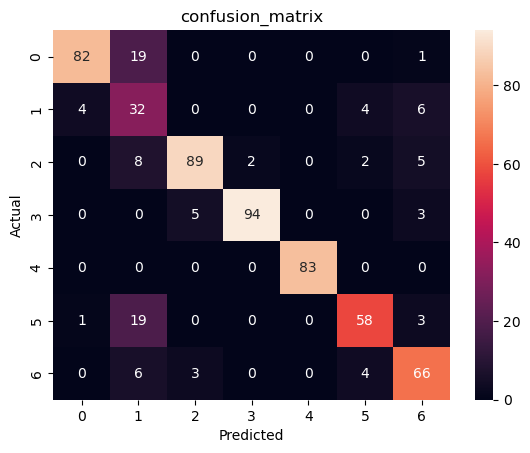

In [15]:
sns.heatmap(conf_mat, annot= True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('confusion_matrix')

In [16]:
# calculating precision, recall, f1-score 
clf_report = classification_report(y_pred, y_test)
print(clf_report)

              precision    recall  f1-score   support

           0       0.94      0.80      0.87       102
           1       0.38      0.70      0.49        46
           2       0.92      0.84      0.88       106
           3       0.98      0.92      0.95       102
           4       1.00      1.00      1.00        83
           5       0.85      0.72      0.78        81
           6       0.79      0.84      0.81        79

    accuracy                           0.84       599
   macro avg       0.84      0.83      0.82       599
weighted avg       0.88      0.84      0.85       599



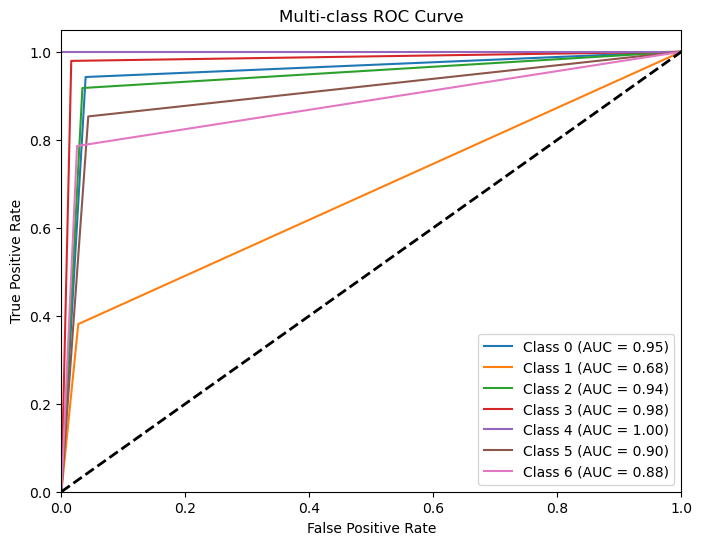

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output if not already done
n_classes = len(y.unique())
if 'y_test_bin' in locals():
    y_test_bin_plot = y_test_bin
else:
    y_test_bin_plot = label_binarize(y_test, classes=range(n_classes))
if 'y_pred_bin' in locals():
    y_pred_bin_plot = y_pred_bin
else:
    y_pred_bin_plot = label_binarize(y_pred, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin_plot[:, i], y_pred_bin_plot[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()